# Statistics on xCodeEval

## Setup

In [1]:
import os
from concurrent.futures import ThreadPoolExecutor

import jpype as jp
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from dotenv import load_dotenv
from tqdm import tqdm

load_dotenv()

if os.path.basename(os.getcwd()) == 'scripts':
  os.chdir('../')

os.getcwd()

'/home/fantasia/repos/projects/assessment'

In [2]:
from src.utils import extract_field_from

dataset = 'xCodeEval'
language = 'java'

snippets = extract_field_from(dataset, language, 'source_code')

len(snippets)

/home/fantasia/repos/projects/assessment/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1849

In [3]:
with open('settings.yml', 'r') as f:
  config = yaml.safe_load(f)

max_workers = min(max(1, config['evaluator']['max_workers']), os.cpu_count())

if not jp.isJVMStarted():
  jp.startJVM('-ea', jvmpath=os.getenv('JVM_PATH'),
                  classpath=[os.getenv('TSFM_CLASSPATH')])
cls = jp.JClass(config['mutator']['class'])

cls

<java class 'org.example.experiment.Mutator'>

In [4]:
sns.set_style('whitegrid')
sns.set_palette('rainbow')

## Statistics

### Distribution of Spot Counts

In [5]:
spot_counts_path = 'data/spot_counts.p'

if os.path.exists(spot_counts_path):
  spot_counts = pd.read_pickle(spot_counts_path)
else:
  with ThreadPoolExecutor(max_workers=max_workers) as executor:
    spot_counts = pd.Series(tqdm(executor.map(cls.countSpots, [language] * len(snippets), snippets), total=len(snippets)))
  spot_counts.to_pickle(spot_counts_path)

spot_counts.describe()

count    1849.000000
mean       26.893456
std        31.612251
min         0.000000
25%         9.000000
50%        18.000000
75%        34.000000
max       404.000000
dtype: float64

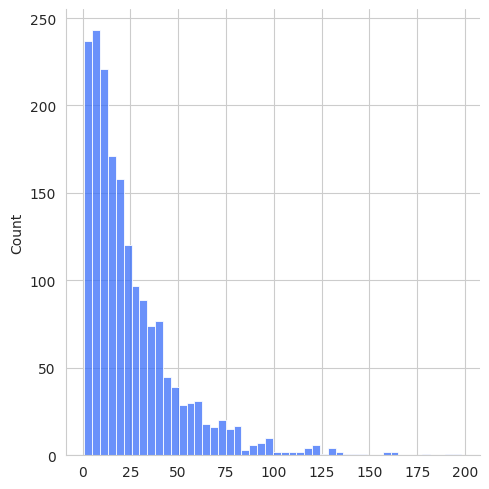

In [6]:
sns.displot(spot_counts[(spot_counts > 0) & (spot_counts < 200)])
plt.show()

### Distribution of Lines in Code

In [7]:
def count_lines(snippet: str) -> int:
  return len(snippet.splitlines())

with ThreadPoolExecutor(max_workers=max_workers) as executor:
  line_counts = pd.Series(tqdm(executor.map(count_lines, snippets), total=len(snippets)))

line_counts.describe()

100%|██████████| 1849/1849 [00:00<00:00, 428515.20it/s]


count    1849.000000
mean      140.904273
std       182.459602
min         1.000000
25%        50.000000
50%       100.000000
75%       172.000000
max      2769.000000
dtype: float64

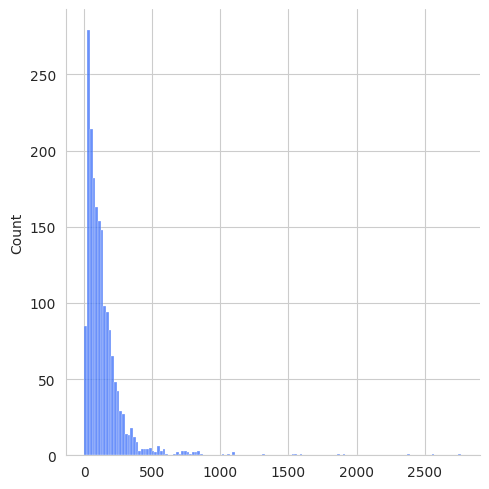

In [8]:
sns.displot(line_counts)
plt.show()

### Distribution of Pairwise Test Case Counts

In [9]:
pairwise_counts_path = 'data/pairwise_counts.p'

if os.path.exists(pairwise_counts_path):
  pairwise_counts = pd.read_pickle(pairwise_counts_path)
else:
  with ThreadPoolExecutor(max_workers=max_workers) as executor:
    pairwise_counts = pd.Series(tqdm(executor.map(cls.countPairwiseCases, [language] * len(snippets), snippets), total=len(snippets)))
  pairwise_counts.to_pickle(pairwise_counts_path)

pairwise_counts.describe()

count    1849.000000
mean       18.586263
std        10.852676
min         0.000000
25%        11.000000
50%        16.000000
75%        26.000000
max        76.000000
dtype: float64

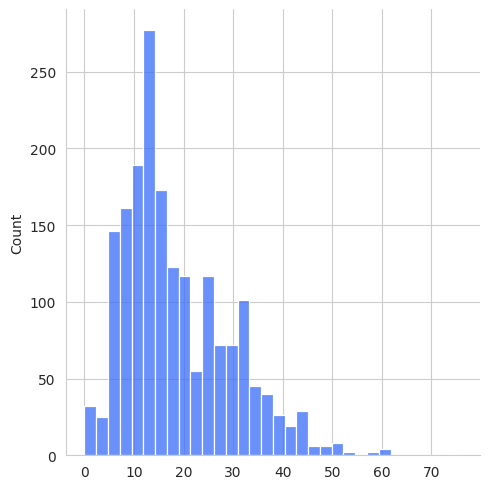

In [10]:
sns.displot(pairwise_counts)
plt.show()